In [1]:
%load_ext autoreload
%autoreload 2
from NLSE import CoupledRings
import numpy as np
import matplotlib.pyplot as plt

c = 299792458

wl_center = 1560e-9
omega_0 = 2 * np.pi * c / wl_center

neff = c / ( 699e-6 * 200e9 )

simulation = CoupledRings(
    neff=neff, 
    FSR_main=200e9,
    FSR_aux=206e9,
    coupling_ring_bus=0.01074,
    coupling_ring_ring=0.006816,
    coupling_ring_drop=0,
    gamma=1.229,
    alpha_int_main=8.643,
    alpha_int_aux=4.321,
    beta_2=40e-27,
    omega_0=omega_0
)

intensity_in = 0.22

A_in = np.sqrt(intensity_in) * np.ones(simulation.time.shape)
A_init = np.zeros(simulation.time.shape)

run_sim = simulation.get_ikeda_map()
A_main, A_aux, A_out, A_drop = run_sim(A_init, A_init, A_in, detuning_main=0.05340, detuning_aux=0.1891, nrt=20000, n_per_step=5)

In [ ]:
from NLSE import CoupledRings
import numpy as np
import matplotlib.pyplot as plt

c = 299792458

wl_center = 1560e-9
omega_0 = 2 * np.pi * c / wl_center

neff = c / ( 699e-6 * 200e9 )

simulation = CoupledRings(
    neff=neff, 
    FSR_main=200e9,
    FSR_aux=206e9,
    coupling_ring_bus=0.00648,
    coupling_ring_ring=1e-10,
    coupling_ring_drop=0,
    gamma=1.229,
    alpha_int_main=8.643,
    alpha_int_aux=4.321,
    beta_2=-40e-27,
    omega_0=omega_0
)

intensity_in = 0.05

A_in = np.sqrt(intensity_in) * np.ones(simulation.time.shape)
A_init = np.zeros(simulation.time.shape)

run_sim = simulation.get_ikeda_map()
A_main, A_aux, A_out, A_drop = run_sim(A_init, A_init, A_in, detuning_main=0.0043, detuning_aux=0.1881, nrt=100000, n_per_step=5)

ValueError: too many values to unpack (expected 2)

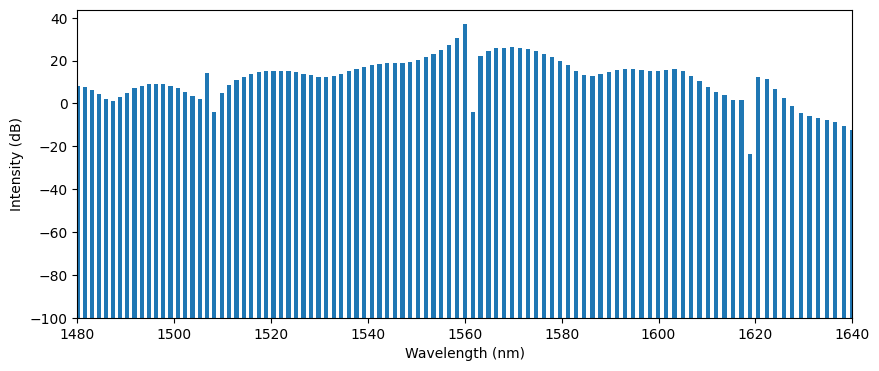

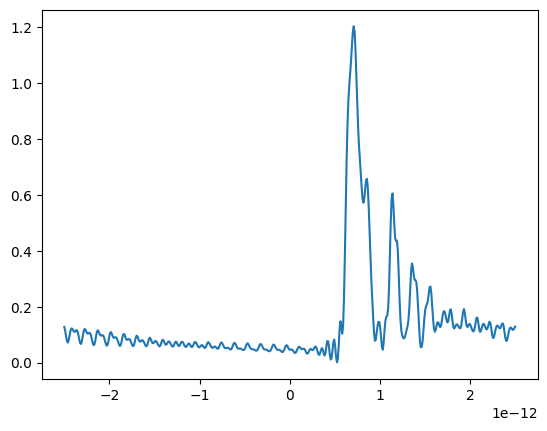

In [2]:
import matplotlib.pyplot as plt

dBm = lambda arr: 10 * np.log10( arr ) + 30

cross_section = np.abs( np.fft.fft(A_main[-1]) ) ** 2 / A_main[0].size ** 2

plt.figure(figsize=(10,4))
plt.bar(1e9 * simulation.wavelength, dBm(cross_section) + 100, width=0.5 * np.mean(np.diff(np.fft.fftshift(1e9 * simulation.wavelength))), bottom=-100, align='center')
# plt.ylim(bottom=-10)
plt.xlim(1480, 1640)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (dB)')
plt.show()

plt.plot(simulation.time, np.abs(A_out[-1])**2)
plt.show()

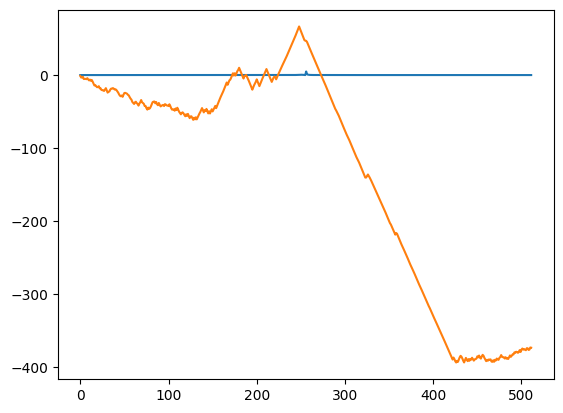

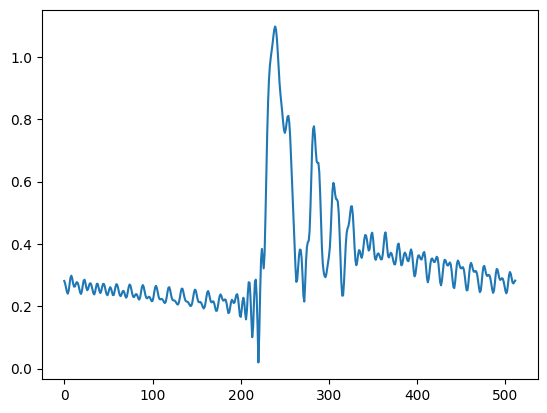

In [41]:
phase = np.unwrap( np.fft.fftshift(np.angle(np.fft.fft(A_main[-1]))) )
plt.plot(np.fft.fftshift(cross_section))
plt.plot(phase)
plt.show()

plt.plot(np.abs(A_out[-1]))
# plt.plot(np.unwrap(np.angle(A_out[-1])))

In [29]:
np.sum((np.abs(np.fft.fft(A_out[-1]) / A_main[0].size)**2)[1:]) / intensity_in

np.float32(0.36553803)

0
112.64001
10000
72.68364
20000
72.6898


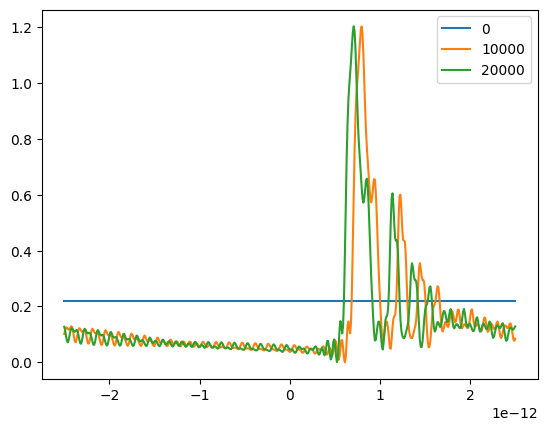

In [ ]:
for ind in range(0, len(A_out), 10000):
    print(ind)
    plt.plot(simulation.time, np.abs(A_out[ind])**2, label=ind)
plt.legend()
plt.show()

In [5]:
simulation.coupling_ring_bus / simulation.cavity_length_main, simulation.coupling_ring_ring / simulation.cavity_length_aux, np.sqrt(simulation.coupling_ring_bus) / simulation.cavity_length_main

(9.270386266094421, 1.4735336194563663e-07, np.float64(115.16229927037543))

In [6]:
simulation.coupling_ring_bus

0.00648

In [8]:
( simulation.alpha_int_main * simulation.cavity_length_main + simulation.coupling_ring_ring + simulation.coupling_ring_bus ) / 2, alpha

NameError: name 'alpha' is not defined

In [7]:
np.fft.fft(A_aux[-1])[0] / np.fft.fft(A_main[-1])[0], np.sqrt(simulation.coupling_ring_ring)

(np.complex64(9.459442e-05-4.366035e-05j), np.float64(1e-05))

In [9]:
np.sqrt(simulation.coupling_ring_ring)

np.float64(1e-05)

In [10]:
np.fft.fft(A_aux[-1])[0] / np.fft.fft(A_main[-1])[0]

np.complex64(9.459442e-05-4.366035e-05j)

In [11]:
alpha_aux = (simulation.coupling_ring_ring + simulation.coupling_ring_drop + simulation.alpha_int_aux * simulation.cavity_length_aux) / 2

np.sqrt(simulation.coupling_ring_ring) / (alpha_aux + 1j * (detuning_aux - simulation.gamma * simulation.cavity_length_aux * 
np.fft.fft(np.abs(A_aux[-1]) ** 2 * A_aux[-1])[0] / np.fft.fft(A_aux[-1])[-1]))

NameError: name 'detuning_aux' is not defined

In [14]:
np.sum(np.fft.fft(A_main[-1])[1:] ** 2)

np.complex64(-3519.5454+5443.164j)

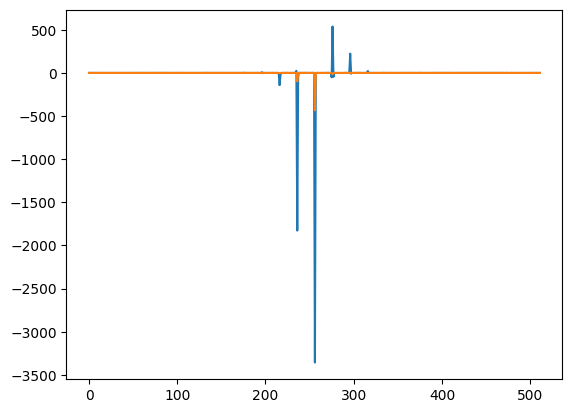

In [13]:
plt.plot(np.fft.fftshift(np.fft.fft(np.abs(A_main[-1]) ** 2 * A_main[-1])).real)
plt.plot(np.fft.fftshift(np.fft.fft(A_main[-1])).real)

In [15]:
-1j * simulation.gamma * simulation.cavity_length_main * np.fft.fft(np.abs(A_main[-1]) ** 2 * A_main[-1])[0] / np.fft.fft(A_main[-1])[0]

np.complex64(7.702628e-05-0.006421635j)

In [4]:
# detuning_main=0.0043
detuning_main = 0.05340
detuning_aux=0.1891

alpha = ( simulation.alpha_int_main * simulation.cavity_length_main + simulation.coupling_ring_bus + simulation.coupling_ring_ring ) / 2
alpha_aux = (simulation.coupling_ring_ring + simulation.coupling_ring_drop + simulation.alpha_int_aux * simulation.cavity_length_aux) / 2
alpha_nl1 = simulation.gamma * simulation.cavity_length_main * \
                np.fft.fft(np.abs(A_main[-1]) ** 2 * A_main[-1])[0] / np.fft.fft(A_main[-1])[0]

alpha_nl2 = np.sqrt(simulation.coupling_ring_ring) * np.fft.fft(A_aux[-1])[0] / np.fft.fft(A_main[-1])[0]

denominator = alpha + 1j * ( - alpha_nl1 ) - alpha_nl2
detuning_effective = denominator.imag
alpha_effective = denominator.real
alpha_effective, simulation.FSR_main * detuning_effective / (2 * np.pi) / 1e6

(np.float64(-0.011483908117723915), np.float64(-418.49089376690574))

In [12]:
alpha + 1j * (-alpha_nl1) - alpha_nl2

np.complex128(-0.011483968880223544-0.013147269952519093j)

5.334129144808399
(0.012965109+0.012848362j)
(0.0014278529-0.00012416026j)


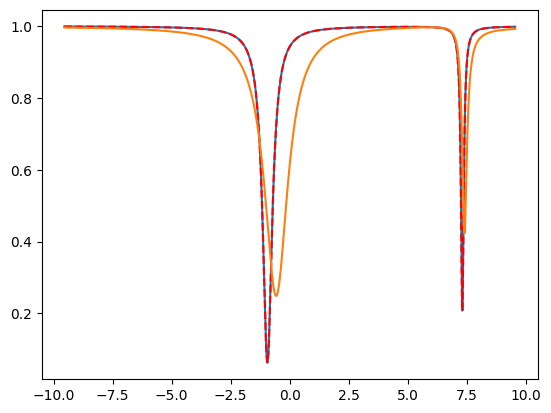

(0.0014278529-0.0001241603j) (0.012965109+0.012848362j)


In [22]:
import matplotlib.pyplot as plt

det = np.linspace(-0.3, 0.3, 10000)
det_freq = simulation.FSR_main * det / ( 2 * np.pi )
# det = np.linspace(-1, 1, 10000)
# plt.axvline(detuning_main)
# I = simulation.coupling_ring_bus / (alpha + 1j * (det - alpha_nl1) - alpha_nl2)
# T = ( 1 - simulation.coupling_ring_bus / (alpha + 1j * ((det - detuning_main) - alpha_nl1) - alpha_nl2) )
detuning_main = 0
detuning_aux = 0.2


print(np.sqrt(simulation.coupling_ring_ring * simulation.FSR_main * simulation.FSR_aux) / np.pi / 1e9)
plt.plot(det_freq / 1e9, simulation.resonance_transmission_linear(det,detuning_main,detuning_aux))
t = 1 - simulation.coupling_ring_bus / (1j * (det - detuning_main) + simulation.coupling_ring_bus / 2 + simulation.alpha_int_main * simulation.cavity_length_main / 2 + simulation.coupling_ring_ring / (1j * (det - detuning_aux) + simulation.coupling_ring_drop / 2 + simulation.alpha_int_aux * simulation.cavity_length_aux / 2))
plt.plot(det_freq / 1e9, np.abs(t) ** 2, 'r--')

# T_linear = 1 - simulation.coupling_ring_bus / ( )

# T = ( 1 - simulation.coupling_ring_bus / ( alpha + 1j * (det - alpha_nl1) - simulation.coupling_ring_ring / (alpha_aux + 1j * (detuning_aux - simulation.gamma * simulation.cavity_length_aux * np.fft.fft(np.abs(A_aux[-1]) ** 2 * A_aux[-1])[0]/np.fft.fft(A_aux[-1])[0])) ) )
alpha_nl_aux = np.fft.fft(np.abs(A_aux[-1]) ** 2 * A_aux[-1])[0] / np.fft.fft(A_aux[-1])[0]
# T = ( 1 - simulation.coupling_ring_bus / ( alpha + 1j * ((det - detuning_main) - alpha_nl1) + simulation.coupling_ring_ring / (alpha_aux + 1j * (det - detuning_aux) - simulation.gamma * simulation.cavity_length_aux * alpha_nl_aux)) )
# plt.plot(det, np.abs(T) ** 2)
plt.plot(det_freq / 1e9 , simulation.resonance_transmission_nonlinear(det, detuning_main, detuning_aux, A_main[-1], A_aux[-1]))
plt.show()
print(simulation.gamma * simulation.cavity_length_aux * alpha_nl_aux, alpha_nl1)


In [9]:
simulation.alpha_int_main * simulation.cavity_length_main + simulation.coupling_ring_ring

0.012857457

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
plt.cla()
# Interactive detuning scan. Assumes the setup cell above has already created
# simulation, run_sim, A_in, A_main, and A_aux.
state = {
    'detuning_main': 0.05340,
    'detuning_aux': 0.1891,
    'intensity_in': intensity_in,
    'A_main_last': A_main[-1].copy(),
    'A_aux_last': A_aux[-1].copy(),
    'runs': 0,
}

main_detuning = widgets.FloatText(value=state['detuning_main'], description='main', step=1e-4, layout=widgets.Layout(width='180px'))
aux_detuning = widgets.FloatText(value=state['detuning_aux'], description='aux', step=1e-4, layout=widgets.Layout(width='180px'))
detuning_step = widgets.FloatText(value=1e-4, description='step', step=1e-5, layout=widgets.Layout(width='180px'))
intensity_control = widgets.FloatText(value=state['intensity_in'], description='intensity', step=0.01, layout=widgets.Layout(width='180px'))
nrt_control = widgets.IntText(value=10000, description='nrt', layout=widgets.Layout(width='180px'))
n_per_step_control = widgets.IntText(value=5, description='n/step', layout=widgets.Layout(width='180px'))
use_latest = widgets.Checkbox(value=True, description='use latest fields')

main_minus = widgets.Button(description='- main', layout=widgets.Layout(width='80px'))
main_plus = widgets.Button(description='+ main', layout=widgets.Layout(width='80px'))
aux_minus = widgets.Button(description='- aux', layout=widgets.Layout(width='80px'))
aux_plus = widgets.Button(description='+ aux', layout=widgets.Layout(width='80px'))
run_button = widgets.Button(description='rerun', button_style='primary', layout=widgets.Layout(width='90px'))
reset_button = widgets.Button(description='reset input', layout=widgets.Layout(width='100px'))
status = widgets.HTML()
out = widgets.Output()


def dBm(arr):
    return 10 * np.log10(np.maximum(arr, np.finfo(float).tiny)) + 30


def plot_latest_spectrum():
    cross_section = np.abs(np.fft.fft(A_main[-1])) ** 2 / A_main[0].size ** 2
    wavelengths_nm = 1e9 * simulation.wavelength
    bar_width = 0.5 * np.mean(np.diff(np.fft.fftshift(wavelengths_nm)))

    plt.figure(figsize=(10, 4))
    plt.bar(wavelengths_nm, dBm(cross_section) + 100, width=bar_width, bottom=-100, align='center')
    # plt.ylim(bottom=-10)
    plt.xlim(1480, 1640)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Intensity (dB)')
    plt.show()


def rerun(_=None):
    global A_main, A_aux, A_in, intensity_in

    run_button.disabled = True
    status.value = 'Running...'
    with out:
        clear_output(wait=True)
        intensity_in = intensity_control.value
        A_in = 1j * np.sqrt(intensity_in) * np.ones(simulation.time.shape)
        A_main_init = state['A_main_last'] if use_latest.value else np.zeros(simulation.time.shape)
        A_aux_init = state['A_aux_last'] if use_latest.value else np.zeros(simulation.time.shape)
        A_main, A_aux = run_sim(
            A_main_init,
            A_aux_init,
            A_in,
            detuning_main=main_detuning.value,
            detuning_aux=aux_detuning.value,
            nrt=nrt_control.value,
            n_per_step=n_per_step_control.value,
        )
        state['A_main_last'] = A_main[-1].copy()
        state['A_aux_last'] = A_aux[-1].copy()
        state['detuning_main'] = main_detuning.value
        state['detuning_aux'] = aux_detuning.value
        state['intensity_in'] = intensity_in
        state['runs'] += 1
        plot_latest_spectrum()
    status.value = f"Run {state['runs']} complete: main={main_detuning.value:.6g}, aux={aux_detuning.value:.6g}, intensity={intensity_in:.6g}"
    run_button.disabled = False


def reset_input(_=None):
    state['A_main_last'] = np.zeros(simulation.time.shape)
    state['A_aux_last'] = np.zeros(simulation.time.shape)
    status.value = 'Input fields reset to zero.'


def step_control(control, direction):
    control.value = control.value + direction * detuning_step.value
    rerun()

main_minus.on_click(lambda _: step_control(main_detuning, -1))
main_plus.on_click(lambda _: step_control(main_detuning, 1))
aux_minus.on_click(lambda _: step_control(aux_detuning, -1))
aux_plus.on_click(lambda _: step_control(aux_detuning, 1))
run_button.on_click(rerun)
reset_button.on_click(reset_input)

controls = widgets.VBox([
    widgets.HBox([main_detuning, aux_detuning, detuning_step, intensity_control]),
    widgets.HBox([main_minus, main_plus, aux_minus, aux_plus, run_button, reset_button, use_latest]),
    widgets.HBox([nrt_control, n_per_step_control, status]),
])

display(controls, out)
status.value = 'Ready. Current spectrum shown below.'
with out:
    clear_output(wait=True)
    plot_latest_spectrum()



Output()